In [1]:
import pandas as pd

df = pd.read_csv('cleaned_data.csv')

for col in df.columns:
    print(col) 

Date of Surgery
Sex
Age
LLIF?
Case/Type of Surgery
Perc screws?
Open
Open Check V2
Standalone XLIF Check
 Retroperitoneal Approach (LLIF ± ALIF)
Anterior + Posterior Apporoach
Osteotomies (yes/no)
osteotomy level
T12-L1
L1-L2
L2-L3
L3-L4
L4-L5
L5-S1
ALIF Count
Lateral Count
ACR (y=1)
ACR level
Additional Procedures w/in surgery
Pre op Diagnosis (back pain, adjacent segment disease, spondy)
BMI
prior back surgeries? (y=1)
Average PI
VALIDATION COLUMN
PI-LL angle mismatch
ABS PI-LL angle mismatch
PI-LL Mismatch Category (1 = mismatch > +/- 9
PI-LL Mismatch Category (1 = mismatch > +/- 10
(1 = PI>50)
Post-op SS
Post-op SS Grouping
Roussouly Class
post PI
post PT
post LL
post SVA
post-op date
most recent PI
most recent PT
most recent LL
most recent SVA
most recent date
subsidence 
titanium v PEEK (T=0,P=1)
cage details
length of hospital stay (d)
post op complications? (Y/N)
infection 1=yes
DVT  1=yes
PE  1=yes
MI 1=yes
infection 
DVT
PE
MI
Hernia
Hematoma
femoral palsy (knee extension wea

In [2]:
clean_feature_cols = [

    # Demographics
    "Sex",
    "Age",
    "BMI",
    "prior back surgeries? (y=1)",

    # Pre-op diagnosis
    "dx_adjacent_segment",
    "dx_spondylolisthesis",
    "dx_spondylosis",
    "dx_stenosis",
    "dx_scoliosis",
    "dx_flat_back",
    "dx_sagittal_imbalance",
    "dx_post_laminectomy",
    "dx_deformity",

    # Case type
    "Case/Type of Surgery",
    "Additional Procedures w/in surgery",

    # Fusion levels
    "T12-L1",
    "L1-L2",
    "L2-L3",
    "L3-L4",
    "L4-L5",
    "L5-S1",

    # Surgical approach / technique
    "Perc screws?",
    "Open",
    "Open Check V2",
    "Standalone XLIF Check",
    "Retroperitoneal Approach (LLIF ± ALIF)",
    "Anterior + Posterior Apporoach",
    "Osteotomies (yes/no)",
    "osteotomy level",
    "ALIF Count",
    "Lateral Count",
    "ACR (y=1)",
    "ACR level",

    # Preoperative spinopelvic parameters
    "Average PI",
    "PI-LL angle mismatch",
    "ABS PI-LL angle mismatch",
    "PI-LL Mismatch Category (1 = mismatch > +/- 9",
    "PI-LL Mismatch Category (1 = mismatch > +/- 10",
    "(1 = PI>50)",

    # Immediate postoperative alignment (allowed)
    "Post-op SS",
    "post PI",
    "post PT",
    "post LL",
    "post SVA",

    # Immediate postop complications (allowed)
    "infection 1=yes",
    "DVT  1=yes",
    "PE  1=yes",
    "MI 1=yes",
    "femoral palsy (knee extension weakness) 1=yes",
    "hip flexion weakness (iliopsoas weakness)  1=yes",
    "acute thigh paresthesia (immediate post op)",
    "psoas hematoma",

    # Hospital course
    "length of hospital stay (d)",
]


In [3]:
clean_feature_cols_asd = [

    # -----------------
    # Demographics
    # -----------------
    "Sex",
    "Age",
    "BMI",
    "prior back surgeries? (y=1)",

    # -----------------
    # Pre-op diagnosis flags (from Pre op Diagnosis text)
    # -----------------
    "dx_adjacent_segment",
    "dx_spondylolisthesis",
    "dx_spondylosis",
    "dx_stenosis",
    "dx_scoliosis",
    "dx_flat_back",
    "dx_sagittal_imbalance",
    "dx_post_laminectomy",
    "dx_deformity",

    # -----------------
    # Fusion levels (index constructs)
    # -----------------
    "T12-L1",
    "L1-L2",
    "L2-L3",
    "L3-L4",
    "L4-L5",
    "L5-S1",

    # Construct summary features you engineered
    "levels_fused_count",
    "construct_span_levels",
    "thoracolumbar_junction",
    "upper_lumbar",
    "lower_lumbar",
    "lumbosacral",

    # -----------------
    # Surgical approach / technique
    # -----------------
    "LLIF?",                # whether lateral/LLIF was done at all
    "Perc screws?",
    "Open",
    "Open Check V2",
    "Standalone XLIF Check",
    "Retroperitoneal Approach (LLIF ± ALIF)",
    "Anterior + Posterior Apporoach",
    "Osteotomies (yes/no)",
    "osteotomy level",
    "ALIF Count",
    "Lateral Count",
    "ACR (y=1)",
    "ACR level",

    # Higher-level surgery flags
    "revision_surgery",
    "deformity_case_text",
    "llif_or_lateral_text",
    "xlif_text",
    "alif_text",

    # -----------------
    # Preoperative spinopelvic parameters
    # -----------------
    "Average PI",
    "PI-LL angle mismatch",
    "ABS PI-LL angle mismatch",
    "PI-LL Mismatch Category (1 = mismatch > +/- 9",
    "PI-LL Mismatch Category (1 = mismatch > +/- 10",
    "(1 = PI>50)",   # this matches your full column list

    # -----------------
    # Immediate postoperative alignment (non-leaky)
    # -----------------
    "Post-op SS",
    "post PI",
    "post PT",
    "post LL",
    "post SVA",

    # -----------------
    # Immediate postop complications (index hospitalization)
    # -----------------
    "infection 1=yes",
    "DVT  1=yes",
    "PE  1=yes",
    "MI 1=yes",
    "femoral palsy (knee extension weakness) 1=yes",
    "hip flexion weakness (iliopsoas weakness)  1=yes",
    "acute thigh paresthesia (immediate post op)",
    "psoas hematoma",

    # -----------------
    # Hospital course
    # -----------------
    "length of hospital stay (d)",
]


In [4]:
import pandas as pd
import numpy as np
from sksurv.util import Surv
from sklearn.model_selection import train_test_split

time_col = "Time Until ASD Diagnosis (months)"


C:\Users\SBSBB\AppData\Local\Temp\ipykernel_33844\341787359.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=series, order=order, ax=ax, palette="muted")
C:\Users\SBSBB\AppData\Local\Temp\ipykernel_33844\341787359.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=series, order=order, ax=ax, palette="muted")
C:\Users\SBSBB\AppData\Local\Temp\ipykernel_33844\341787359.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=series, order=order, ax=ax, palette="muted")


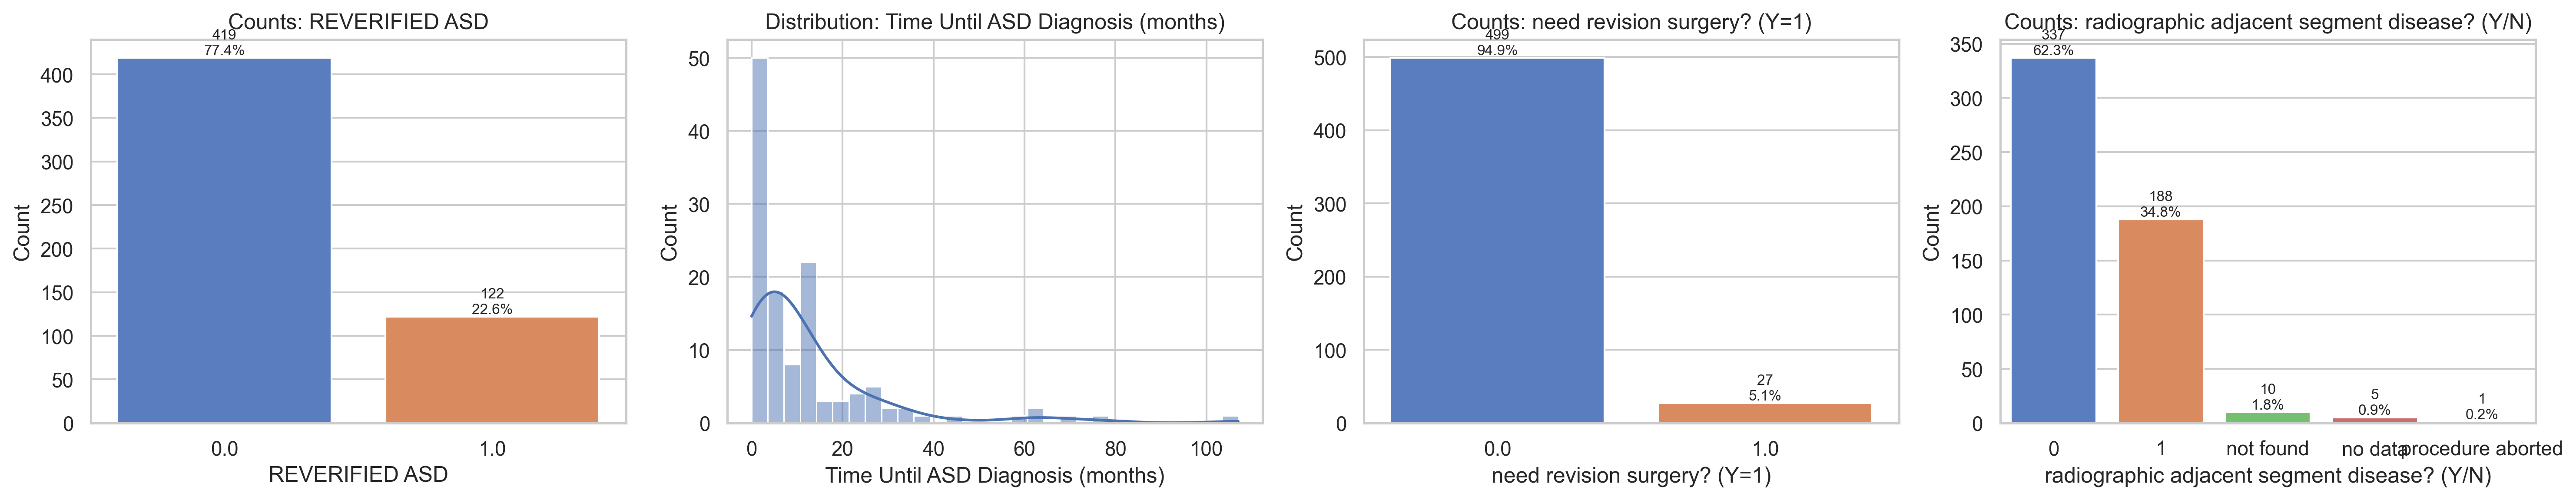

In [5]:
import seaborn as sns
from pandas.api import types as pd_types

import matplotlib.pyplot as plt

# helper to find column with case-insensitive / partial matching
def find_col(df, name):
    name_l = name.lower()
    # exact lower match
    for c in df.columns:
        if c.lower() == name_l:
            return c
    # substring match
    for c in df.columns:
        if name_l in c.lower() or c.lower() in name_l:
            return c
    return None

# desired columns (use existing notebook variables where available)
cols_wanted = [
    "REVERIFIED ASD",                    # user: 'Reverified ASD'
    time_col,                            # 'Time Until ASD Diagnosis (months)' (variable from notebook)
    "need revision surgery? (Y=1)",      # user-provided name
    "radiographic adjacent segment disease? (Y/N)"
]

# resolve to actual df columns, skip missing
cols = []
for nm in cols_wanted:
    c = find_col(df, nm)
    if c is None:
        print(f"Column not found (skipping): {nm}")
    else:
        cols.append(c)

if not cols:
    raise RuntimeError("No plotting columns found in df.")

sns.set(style="whitegrid")

n = len(cols)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), dpi=300, squeeze=False)
axes = axes.flatten()

for ax, col in zip(axes, cols):
    series = df[col].dropna()
    # decide continuous vs categorical/binary
    is_numeric = pd_types.is_numeric_dtype(series.dtype)
    unique_vals = series.nunique(dropna=True)
    if is_numeric and unique_vals > 10:
        # distribution for continuous
        sns.histplot(series.astype(float), kde=True, bins=30, ax=ax, color="C0")
        ax.set_title(f"Distribution: {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
    else:
        # histogram / countplot for categorical / binary
        order = series.value_counts(dropna=True).index
        sns.countplot(x=series, order=order, ax=ax, palette="muted")
        ax.set_title(f"Counts: {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        # annotate counts / percentages
        totals = len(series)
        for p in ax.patches:
            height = p.get_height()
            if height == 0:
                continue
            pct = 100 * height / totals
            ax.annotate(f"{int(height)}\n{pct:.1f}%", (p.get_x() + p.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd


# 2. Clean column names a bit
df.columns = (
    df.columns
      .str.strip()
      .str.replace("\n", " ", regex=False)
)

df.columns



Index(['Date of Surgery', 'Sex', 'Age', 'LLIF?', 'Case/Type of Surgery',
       'Perc screws?', 'Open', 'Open Check V2', 'Standalone XLIF Check',
       'Retroperitoneal Approach (LLIF ± ALIF)',
       ...
       'alif_text', 'dx_adjacent_segment', 'dx_spondylolisthesis',
       'dx_spondylosis', 'dx_stenosis', 'dx_scoliosis', 'dx_flat_back',
       'dx_sagittal_imbalance', 'dx_post_laminectomy', 'dx_deformity'],
      dtype='object', length=116)

In [7]:
target = "Time Until ASD Diagnosis (months)"

# Keep only rows where the target is known (patients who actually developed ASD)
asd_df = df[df[target].notna()].copy()
asd_df.shape


(125, 116)

In [8]:
import pandas as pd
import numpy as np

from sksurv.util import Surv
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from numpy.linalg import LinAlgError

import torch
import torchtuples as tt
from pycox.models import CoxPH as CoxPH_NN

# ---------------------------
# 1. Define columns & labels
# ---------------------------

event_col = "REVERIFIED ASD"
time_asd_col = "Time Until ASD Diagnosis (months)"
time_no_asd_col = "Time Without_ASD (months)"   # used ONLY for label, not as feature

# df is assumed to be your cleaned dataframe (e.g. df_lace or df_clean)

df_surv = df.copy()

# event: 1 if ASD, else 0
df_surv[event_col] = df_surv[event_col].fillna(0).astype(int)

# time: ASD time if event==1, otherwise Time Without_ASD
df_surv["time_surv"] = np.where(
    df_surv[event_col] == 1,
    df_surv[time_asd_col],
    df_surv[time_no_asd_col],
)

# Drop rows with missing survival time
df_surv = df_surv.dropna(subset=["time_surv"])

print("Full cohort survival rows:", df_surv.shape[0])
print("Events (ASD):", int(df_surv[event_col].sum()))
print("Non-events:", int((df_surv[event_col] == 0).sum()))

# ---------------------------------
# 2. Feature preprocessing
# ---------------------------------

X = df_surv[clean_feature_cols_asd].copy()

# 2a. Coerce numeric-like columns
numeric_like_cols = [
    "BMI",
    "ALIF Count",
    "Lateral Count",
    "Average PI",
    "PI-LL angle mismatch",
    "ABS PI-LL angle mismatch",
    "Post-op SS",
    "post PI",
    "post PT",
    "post LL",
    "post SVA",
    "length of hospital stay (d)",
]

for col in numeric_like_cols:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

# 2b. One-hot encode categorical columns
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
print("Categorical feature columns:", cat_cols)

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Simple imputation: fill remaining NaNs
X_encoded = X_encoded.fillna(0)

# Targets
durations_all = df_surv["time_surv"].astype(float).values
events_all = df_surv[event_col].astype(bool).values

print("Final feature matrix shape:", X_encoded.shape)

# ---------------------------------
# 3. Cross-validated classical survival models
# ---------------------------------

# Define models (we'll re-instantiate them inside each fold)
def build_models():
    return {
        "coxph": CoxPHSurvivalAnalysis(alpha=1.0),
        "rsf": RandomSurvivalForest(
            n_estimators=300,
            min_samples_split=10,
            min_samples_leaf=10,
            n_jobs=-1,
            random_state=42,
        ),
        "gbsa": GradientBoostingSurvivalAnalysis(
            learning_rate=0.05,
            max_depth=3,
            n_estimators=300,
            random_state=42,
        ),
    }

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

cv_results = {name: [] for name in build_models().keys()}
cv_results_deepsurv = []

X_values = X_encoded.values

fold_idx = 1

for train_idx, test_idx in skf.split(X_values, events_all):
    print(f"\n===== Fold {fold_idx}/{n_splits} =====")
    fold_idx += 1

    X_train = X_values[train_idx]
    X_test = X_values[test_idx]
    durations_train = durations_all[train_idx]
    durations_test = durations_all[test_idx]
    events_train = events_all[train_idx]
    events_test = events_all[test_idx]

    # Build sksurv Surv objects
    y_train = Surv.from_arrays(event=events_train, time=durations_train)
    y_test = Surv.from_arrays(event=events_test, time=durations_test)

    # ------------------
    # Classical models
    # ------------------
    models = build_models()

    for name, model in models.items():
        try:
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            ci = concordance_index_censored(
                events_test,
                durations_test,
                pred
            )[0]
            cv_results[name].append(ci)
            print(f"{name} C-index (fold): {ci:.3f}")
        except LinAlgError:
            print(f"Skipping {name} in this fold: singular matrix.")
            cv_results[name].append(np.nan)


# ---------------------------------
# 4. Summarize CV results
# ---------------------------------

print("\n===== Cross-validated C-index (mean ± SD) =====")
for name, scores in cv_results.items():
    scores_arr = np.array(scores, dtype=float)
    mean_ci = np.nanmean(scores_arr)
    std_ci = np.nanstd(scores_arr)
    print(f"{name}: {mean_ci:.3f} ± {std_ci:.3f} over {n_splits} folds")



Full cohort survival rows: 546
Events (ASD): 122
Non-events: 424
Categorical feature columns: ['osteotomy level', 'ACR level']
Final feature matrix shape: (546, 93)

===== Fold 1/5 =====
coxph C-index (fold): 0.502
rsf C-index (fold): 0.464
gbsa C-index (fold): 0.505

===== Fold 2/5 =====
coxph C-index (fold): 0.554
rsf C-index (fold): 0.611
gbsa C-index (fold): 0.576

===== Fold 3/5 =====
coxph C-index (fold): 0.546
rsf C-index (fold): 0.595
gbsa C-index (fold): 0.577

===== Fold 4/5 =====
coxph C-index (fold): 0.626
rsf C-index (fold): 0.673
gbsa C-index (fold): 0.652

===== Fold 5/5 =====
coxph C-index (fold): 0.562
rsf C-index (fold): 0.608
gbsa C-index (fold): 0.512

===== Cross-validated C-index (mean ± SD) =====
coxph: 0.558 ± 0.040 over 5 folds
rsf: 0.590 ± 0.069 over 5 folds
gbsa: 0.564 ± 0.053 over 5 folds
